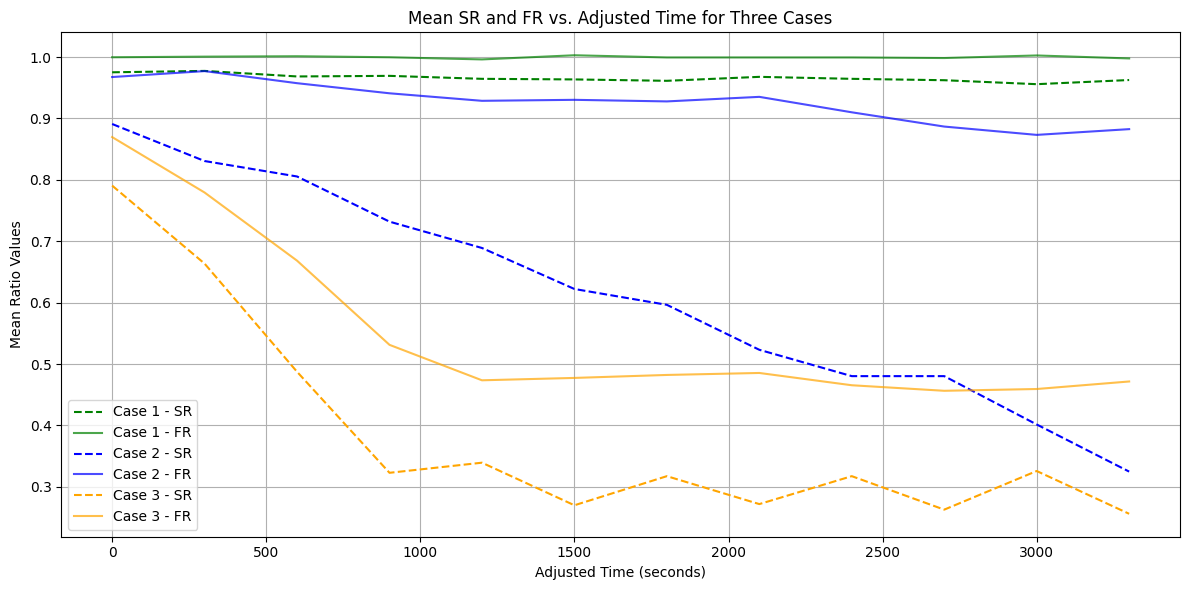

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# File list and labels
files = [
    ('case1aggregatedv3.csv', 'Case 1'),
    ('case2aggregatedv3.csv', 'Case 2'),
    ('case3aggregatedv3.csv', 'Case 3')
]

# Parameters
distance_start = 0
distance_end   = 3000
time_start     = 55200
time_end       = 58500
min_time       = time_start  # for adjusted time

# Set up the plot
plt.figure(figsize=(12, 6))

# Colors for each case
colors = ['green', 'blue', 'orange']

# Loop through each file
for (file_path, label), color in zip(files, colors):
    # Load and preprocess
    df = pd.read_csv(file_path)
    df["interval_begin"] = df["interval_begin"].astype(int)
    df["pos"] = df["pos"].astype(int)
    df = df.sort_values(by=["interval_begin", "pos"])
    df["adjusted_time"] = df["interval_begin"] - min_time

    # Filter
    filtered_df = df[
        (df["pos"] >= distance_start) & (df["pos"] <= distance_end) &
        (df["interval_begin"] >= time_start) & (df["interval_begin"] <= time_end)
    ]

    # Group by adjusted time and take mean
    mean_ratios = filtered_df.groupby("adjusted_time")[["SPR", "FR"]].mean().reset_index()

    # Plot SR and FR
    plt.plot(mean_ratios['adjusted_time'], mean_ratios['SPR'], label=f'{label} - SR', linestyle='--', color=color)
    plt.plot(mean_ratios['adjusted_time'], mean_ratios['FR'], label=f'{label} - FR', linestyle='-',  color=color, alpha=0.7)

# Formatting
plt.xlabel('Adjusted Time (seconds)')
plt.ylabel('Mean Ratio Values')
plt.title('Mean SR and FR vs. Adjusted Time for Three Cases')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()


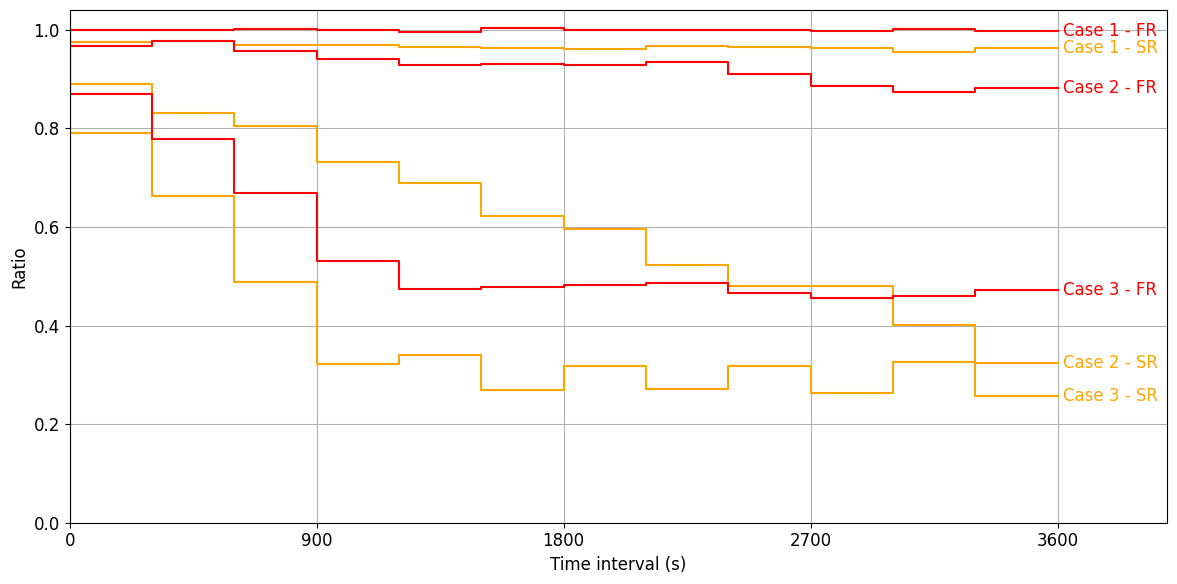

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12})

# File list and labels
files = [
    ('case1aggregatedv3.csv', 'Case 1'),
    ('case2aggregatedv3.csv', 'Case 2'),
    ('case3aggregatedv3.csv', 'Case 3')
]

# Marker styles for each case
markers = ['o', 's', 'D']  # circle, square, diamond

# Plot parameters
distance_start = 0
distance_end   = 3000
time_start     = 54900
time_end       = 58500
min_time       = time_start  # for adjusted time

fig, ax = plt.subplots(figsize=(12, 6))

# Loop through each file with assigned marker
for (file_path, label), marker in zip(files, markers):
    df = pd.read_csv(file_path)
    df["interval_begin"] = df["interval_begin"].astype(int)
    df["pos"] = df["pos"].astype(int)
    df = df.sort_values(by=["interval_begin", "pos"])
    df["adjusted_time"] = df["interval_begin"] - min_time

    # Filter
    filtered_df = df[
        (df["pos"] >= distance_start) & (df["pos"] <= distance_end) &
        (df["interval_begin"] >= time_start) & (df["interval_begin"] <= time_end)
    ]

    # Group and mean
    mean_ratios = filtered_df.groupby("adjusted_time")[["SPR", "FR"]].mean().reset_index()

    # Plot SR (orange dashed)
    ax.step(mean_ratios['adjusted_time'], mean_ratios['SPR'],
             linestyle='-', color='orange')
    
    # Label SR at the end
    ax.text(mean_ratios['adjusted_time'].iloc[-1] + 20,
            mean_ratios['SPR'].iloc[-1],
            f'{label} - SR',
            color='orange',
            va='center')

    # Plot FR (red solid)
    ax.step(mean_ratios['adjusted_time'], mean_ratios['FR'],
             linestyle='-', color='red')
    
    # Label FR at the end
    ax.text(mean_ratios['adjusted_time'].iloc[-1] + 20,
            mean_ratios['FR'].iloc[-1],
            f'{label} - FR',
            color='red',
            va='center')

# Formatting
ax.set_xlabel('Time interval (s)')
ax.set_ylabel('Ratio')
ax.set_xlim(0,4000)  # Ensure x-axis starts at 0
ax.set_ylim(bottom=0)  # Ensure y-axis starts at 0
ax.set_xticks(range(0, 3901, 900)) 
# ax.set_title('Mean SR and FR vs. Adjusted Time for Three Cases')
ax.grid(True)
# Optional: comment out the legend if using inline labels only
# ax.legend()
plt.tight_layout()
plt.savefig('scene2-mean_SR_FR_cases.pdf', dpi=300, bbox_inches='tight')
plt.show()


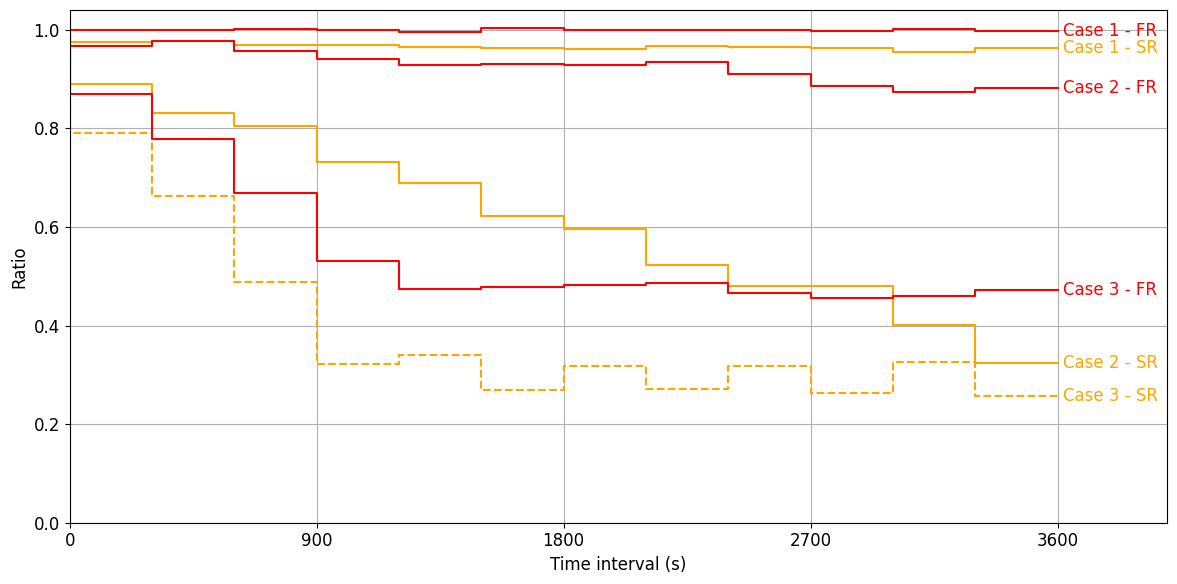

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12})

# File list and labels
files = [
    ('case1aggregatedv3.csv', 'Case 1'),
    ('case2aggregatedv3.csv', 'Case 2'),
    ('case3aggregatedv3.csv', 'Case 3')
]

# Marker styles for each case (still unused but kept for reference)
markers = ['o', 's', 'D']  # circle, square, diamond

# Plot parameters
distance_start = 0
distance_end   = 3000
time_start     = 54900
time_end       = 58500
min_time       = time_start  # for adjusted time

fig, ax = plt.subplots(figsize=(12, 6))

# Loop through each file with assigned marker
for (file_path, label), marker in zip(files, markers):
    df = pd.read_csv(file_path)
    df["interval_begin"] = df["interval_begin"].astype(int)
    df["pos"] = df["pos"].astype(int)
    df = df.sort_values(by=["interval_begin", "pos"])
    df["adjusted_time"] = df["interval_begin"] - min_time

    # Filter
    filtered_df = df[
        (df["pos"] >= distance_start) & (df["pos"] <= distance_end) &
        (df["interval_begin"] >= time_start) & (df["interval_begin"] <= time_end)
    ]

    # Group and mean
    mean_ratios = filtered_df.groupby("adjusted_time")[["SPR", "FR"]].mean().reset_index()

    # Plot SR (orange solid)
    sr_linestyle = '--' if label == 'Case 3' else '-'
    ax.step(mean_ratios['adjusted_time'], mean_ratios['SPR'],
             linestyle=sr_linestyle, color='orange')
    
    # Label SR at the end
    ax.text(mean_ratios['adjusted_time'].iloc[-1] + 20,
            mean_ratios['SPR'].iloc[-1],
            f'{label} - SR',
            color='orange',
            va='center')

    # Plot FR (Case 3 dashed, others solid)
    fr_linestyle = '--' if label == 'Case 3' else '-'
    ax.step(mean_ratios['adjusted_time'], mean_ratios['FR'],
             linestyle='-', color='red')
    
    # Label FR at the end
    ax.text(mean_ratios['adjusted_time'].iloc[-1] + 20,
            mean_ratios['FR'].iloc[-1],
            f'{label} - FR',
            color='red',
            va='center')

# Formatting
ax.set_xlabel('Time interval (s)')
ax.set_ylabel('Ratio')
ax.set_xlim(0, 4000)  # Ensure x-axis starts at 0
ax.set_ylim(bottom=0)  # Ensure y-axis starts at 0
ax.set_xticks(range(0, 3901, 900)) 
ax.grid(True)
plt.tight_layout()
plt.savefig('scene2-mean_SR_FR_cases.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [20]:
import pandas as pd

# File list and labels
files = [
    ('case1aggregatedv3.csv', 'case1_mean_ratios.csv'),
    ('case2aggregatedv3.csv', 'case2_mean_ratios.csv'),
    ('case3aggregatedv3.csv', 'case3_mean_ratios.csv')
]

# Analysis window
distance_start = 0
distance_end   = 3000
time_start     = 54900
time_end       = 58500
min_time       = time_start  # for adjusted time

for input_file, output_file in files:
    # Load and preprocess
    df = pd.read_csv(input_file)
    df["interval_begin"] = df["interval_begin"].astype(int)
    df["pos"] = df["pos"].astype(int)
    df = df.sort_values(by=["interval_begin", "pos"])
    df["adjusted_time"] = df["interval_begin"] - min_time

    # Filter relevant rows
    filtered_df = df[
        (df["pos"] >= distance_start) & (df["pos"] <= distance_end) &
        (df["interval_begin"] >= time_start) & (df["interval_begin"] <= time_end)
    ]

    # Compute mean SPR and FR grouped by adjusted time
    mean_ratios = filtered_df.groupby("adjusted_time")[["SPR", "FR"]].mean().reset_index()

    # Save to CSV
    mean_ratios.to_csv(output_file, index=False)
    print(f"Saved: {output_file}")


Saved: case1_mean_ratios.csv
Saved: case2_mean_ratios.csv
Saved: case3_mean_ratios.csv
